⚠️ Cảnh báo MySQL (Query thành công nhưng database không có dữ liệu (0 dòng).). Tự động chuyển sang đọc file CSV dự phòng...
✅ Đã load dữ liệu thành công từ file CSV cha.

🚀 Đang load mô hình XGBoost Regression từ file...
✅ Load mô hình Regression thành công!

🚀 Đang load mô hình XGBoost Classification từ file...
✅ Load mô hình Classification thành công!

🧬 Đang tính toán SHAP values dựa trên TreeExplainer từ mô hình đã load...
📊 Hiển thị SHAP Summary Plot cho Mô hình Hồi quy...


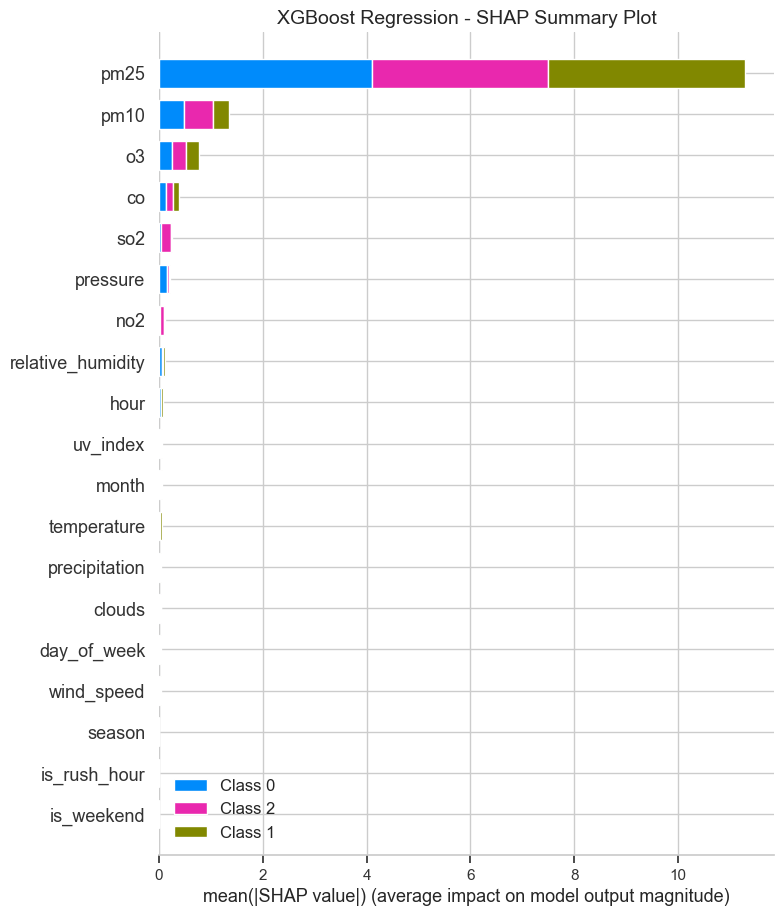

📊 Hiển thị SHAP Summary Plot cho Mô hình Phân loại ...


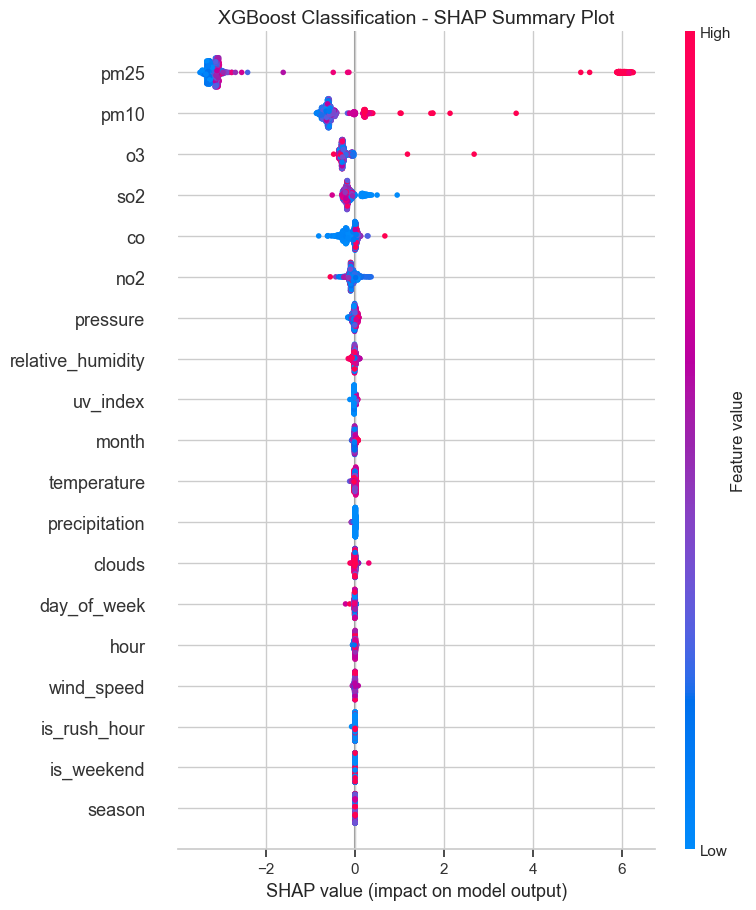


💡 Trực quan Waterfall Plot cho thời điểm đỉnh điểm ô nhiễm


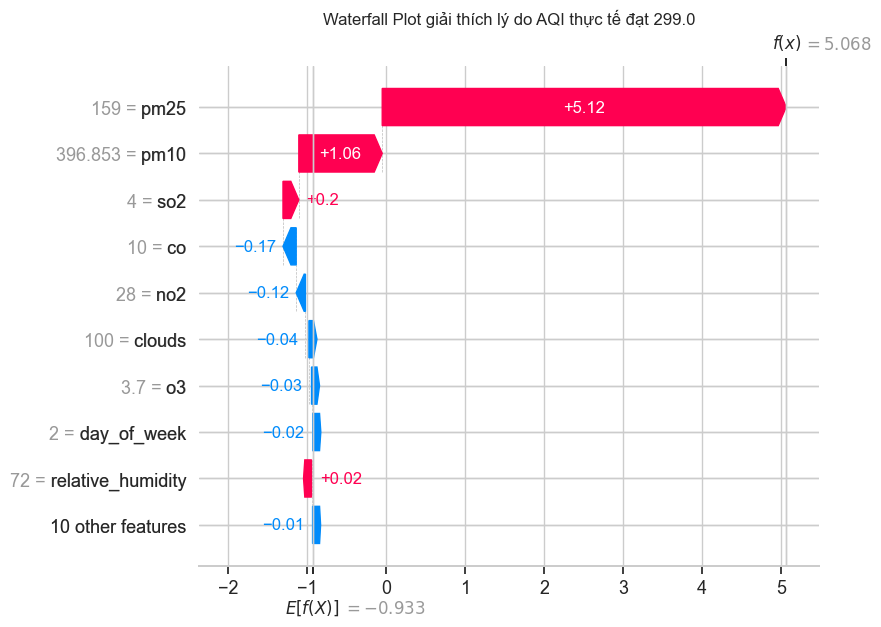


📈 Hiển thị Dependency Plot cho biến PM2.5 tương tác với Độ ẩm (Humidity)...


<Figure size 1000x600 with 0 Axes>

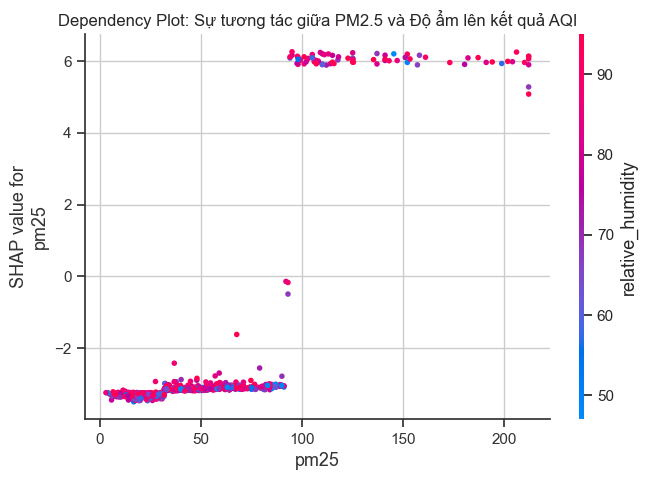


════════════════════════════════════════════════════════════
🏆 KẾT LUẬN: Feature drive chỉ số AQI nhiều nhất toàn cục là: 'PM25'
📂 Đã tải thành công các mô hình tốt nhất từ: 'library_framework/'
✨ Tiến trình phân tích báo cáo kỹ thuật hoàn tất hoàn hảo.
════════════════════════════════════════════════════════════


In [ ]:
import pandas as pd
import numpy as np
import warnings
import shap
import joblib
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sqlalchemy import create_engine
from dotenv import load_dotenv
import xgboost as xgb 

# Tải cấu hình bảo mật từ file .env
load_dotenv(dotenv_path=os.path.join(os.path.dirname(__file__), '../.env') if '__file__' in locals() else '.env')
warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (10, 6)
sns.set_theme(style="whitegrid")

DB_USER = os.getenv("DB_USER")
DB_PASSWORD = os.getenv("DB_PASSWORD")
DB_HOST = os.getenv("DB_HOST")
DB_NAME = os.getenv("DB_NAME")
DB_PORT = os.getenv("DB_PORT")

if DB_PORT is None or DB_PORT == "None" or DB_PORT == "":
    DB_PORT = 3307
else:
    DB_PORT = int(DB_PORT)
    
df = None
try:
    engine = create_engine(f"mysql+pymysql://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}")
    
    query = """
        SELECT 
            tg.local_time, tg.year, tg.month, tg.hour, tg.day_of_week, tg.is_weekend, tg.is_rush_hour, tg.season,
            tt.clouds, tt.precipitation, tt.pressure, tt.relative_humidity, tt.temperature, tt.uv_index, tt.wind_speed,
            ck.co, ck.no2, ck.o3, ck.pm10, ck.pm25, ck.so2, ck.aqi
        FROM thoi_gian tg
        INNER JOIN thoi_tiet tt ON tg.local_time = tt.local_time
        INNER JOIN chat_luong_khong_khi ck ON tg.local_time = ck.local_time
    """
    df = pd.read_sql(query, con=engine)
    engine.dispose()
    
    if df is None or df.empty:
        raise ValueError("Query thành công nhưng database không có dữ liệu (0 dòng).")
        
    print(f"✅ Kết nối MySQL thành công. Đã lấy {len(df)} dòng dữ liệu từ database.")
    
except Exception as e:
    print(f"⚠️ Cảnh báo MySQL ({e}). Tự động chuyển sang đọc file CSV dự phòng...")
    try:
        df = pd.read_csv('../clean/hanoi_aqi_cleaned.csv')
        print("✅ Đã load dữ liệu thành công từ file CSV cha.")
    except Exception:
        df = pd.read_csv('./hanoi_aqi_cleaned.csv')
        print("✅ Đã load dữ liệu thành công từ file CSV cục bộ.")
if df is None or df.empty:
    raise ValueError("❌ LỖI NGHIÊM TRỌNG: Không thể tìm thấy dữ liệu từ MySQL lẫn file CSV, hoặc file trống!")

SEASON_MAP = {0: 'Đông', 1: 'Xuân', 2: 'Hè', 3: 'Thu'}
df.columns = df.columns.str.strip().str.lower()
df['local_time'] = pd.to_datetime(df['local_time'], errors='coerce')
df['season_name'] = df['season'].map(SEASON_MAP)

FEATURES = [
    'co', 'no2', 'o3', 'pm10', 'pm25', 'so2', 'clouds', 'precipitation', 
    'pressure', 'relative_humidity', 'temperature', 'uv_index', 'wind_speed',
    'month', 'hour', 'day_of_week', 'is_weekend', 'is_rush_hour', 'season'
]

FEATURES = [f for f in FEATURES if f in df.columns]

TARGET_REG = 'aqi'
TARGET_CLS = 'aqi_label'  

if TARGET_CLS not in df.columns and TARGET_REG in df.columns:
    df[TARGET_CLS] = pd.cut(df[TARGET_REG], bins=[-1, 100, 200, 999], labels=[0, 1, 2]).astype(int)

# Tách dữ liệu Train (<2025) và Test (2025)
train = df[df['year'] < 2025].copy()
test = df[df['year'] == 2025].copy()

X_train = train[FEATURES].fillna(train[FEATURES].median()).astype(float)
y_train_reg = train[TARGET_REG].fillna(train[TARGET_REG].median())
y_train_cls = train[TARGET_CLS].fillna(train[TARGET_CLS].mode()[0])

X_test = test[FEATURES].fillna(train[FEATURES].median()).astype(float)

os.makedirs('library_framework', exist_ok=True)

print("\n🚀 Đang load mô hình XGBoost Regression từ file...")
try:
    xgb_reg = joblib.load('library_framework/best_model_classification.pkl')
    print("✅ Load mô hình Regression thành công!")
except Exception as e:
    print(f"❌ Lỗi khi load mô hình Regression: {e}")

print("\n🚀 Đang load mô hình XGBoost Classification từ file...")
try:
    xgb_cls = joblib.load('library_framework/best_model_classification.pkl')
    print("✅ Load mô hình Classification thành công!")
except Exception as e:
    print(f"❌ Lỗi khi load mô hình Classification: {e}")

# ══════════════════════════════════════════════════════
#  GIẢI THÍCH MÔ HÌNH VỚI SHAP TREEEXPLAINER
# ══════════════════════════════════════════════════════
print("\n🧬 Đang tính toán SHAP values dựa trên TreeExplainer từ mô hình đã load...")
X_shap = X_train.sample(n=min(1000, len(X_train)), random_state=42)

try:
    explainer_reg = shap.TreeExplainer(xgb_reg)
    shap_values_reg = explainer_reg(X_shap)
    
    explainer_cls = shap.TreeExplainer(xgb_cls)
    shap_values_cls = explainer_cls(X_shap)

    #1 SHAP Summary Plot (Toàn cục)
    print("📊 Hiển thị SHAP Summary Plot cho Mô hình Hồi quy...")
    plt.figure(figsize=(10, 6))
    shap.summary_plot(shap_values_reg, X_shap, show=False)
    plt.title("XGBoost Regression - SHAP Summary Plot", fontsize=14)
    plt.show()

    print("📊 Hiển thị SHAP Summary Plot cho Mô hình Phân loại ...")
    plt.figure(figsize=(10, 6))
    if hasattr(shap_values_cls, "values") and len(shap_values_cls.values.shape) == 3:
        shap.summary_plot(shap_values_cls.values[:, :, -1], X_shap, show=False)
    else:
        shap.summary_plot(shap_values_cls, X_shap, show=False)
    plt.title("XGBoost Classification - SHAP Summary Plot", fontsize=14)
    plt.show()

    #2 Waterfall Plot: Giải thích chi tiết 1 dự đoán cụ thể khi AQI chạm ngưỡng ~300
    if len(test) > 0 and TARGET_REG in test.columns:
        example_idx = (test[TARGET_REG] - 300).abs().idxmin()
        example_x = test.loc[[example_idx]][FEATURES].astype(float)
        
        shap_single_reg = explainer_reg(example_x)
        
        print(f"\n💡 Trực quan Waterfall Plot cho thời điểm đỉnh điểm ô nhiễm")
        plt.figure(figsize=(11, 6))
        
        if len(shap_single_reg.shape) == 3:
            shap.plots.waterfall(shap_single_reg[0, :, -1], show=False)
        else:
            shap.plots.waterfall(shap_single_reg[0], show=False)
            
        plt.title(f"Waterfall Plot giải thích lý do AQI thực tế đạt {test.loc[example_idx, TARGET_REG]:.1f}", fontsize=12)
        plt.show()

    #3 Dependency Plot: PM2.5 ảnh hưởng đến AQI thế nào khi các feature khác thay đổi
    if 'pm25' in FEATURES and 'relative_humidity' in FEATURES:
        print("\n📈 Hiển thị Dependency Plot cho biến PM2.5 tương tác với Độ ẩm (Humidity)...")
        plt.figure(figsize=(10, 6))
        
        shap_vals_for_plot = shap_values_reg.values
        if len(shap_vals_for_plot.shape) == 3:
            shap_vals_for_plot = shap_vals_for_plot[:, :, -1]
            
        shap.dependence_plot('pm25', shap_vals_for_plot, X_shap, interaction_index='relative_humidity', show=False)
        plt.title('Dependency Plot: Sự tương tác giữa PM2.5 và Độ ẩm lên kết quả AQI', fontsize=12)
        plt.show()
        
    
    if hasattr(shap_values_reg, "values"):
        vals = shap_values_reg.values
    else:
        vals = shap_values_reg

    if len(vals.shape) == 3:
        importance_array = np.abs(vals).mean(axis=0).mean(axis=1)
    else:
        importance_array = np.abs(vals).mean(axis=0)

    feat_imp = pd.DataFrame({'Feature': FEATURES, 'Importance': importance_array})
    top_f = feat_imp.sort_values('Importance', ascending=False).iloc[0]['Feature']

    print("\n" + "═"*60)
    print(f"🏆 KẾT LUẬN: Feature drive chỉ số AQI nhiều nhất toàn cục là: '{top_f.upper()}'")
    print(f"📂 Đã tải thành công các mô hình tốt nhất từ: 'library_framework/'")
    print("✨ Tiến trình phân tích báo cáo kỹ thuật hoàn tất hoàn hảo.")
    print("═"*60)
except Exception as e:
    import traceback
    print("❌ LỖI CHI TIẾT TẠI SHAP:")
    print(traceback.format_exc())